# $H_2$ entanglement analysis

This compact three-file release applies the spin-resolved entanglement and
correlation measures introduced in arXiv:2604.07633v1—applied there to
$H_2O$—to neutral $H_2$ along its dissociation coordinate.

The primary calculation uses the cc-pVDZ basis and evaluates the exact
finite-basis ground state together with a low-temperature Gibbs state projected
onto the fixed-$M_S=0$ sector. The reported observables include the spin-up–
spin-down entanglement entropy, total and two-body mutual information, and total
and two-body opposite-spin negativity.

The calculation is organized in three files:

| File | Role |
|---|---|
| [`main.ipynb`](main.ipynb) | calculation workflow, validation summary, and figures |
| [`h2_core.py`](h2_core.py) | electronic structure, spin purification, observables, and thermal mixture |
| [`h2_rdm.py`](h2_rdm.py) | compact particle-RDM contraction engine |

## 1. Model and conventions

* **Molecule:** Neutral $\mathrm{H_2}$, with one H atom at the origin and the
  other at $(0,0,R)$. Spherical cc-pVDZ contains 10 spatial orbitals,
  corresponding to 20 interleaved spin orbitals
  ($\alpha \mapsto 2p$, $\beta \mapsto 2p+1$).

* **Finite-basis exact solution:** The complete
  $(N_\uparrow, N_\downarrow) = (1,1)$, $M_S = 0$ sector is retained. Its
  dimension is $10^2 = 100$, and its full Hamiltonian is diagonalized.

* **Particle-RDM convention:** We use the convention of the reference
  manuscript. For the present two-electron system,

  $$
  \operatorname{Tr} \rho^{(1)}_\uparrow
  = \operatorname{Tr} \rho^{(1)}_\downarrow
  = \operatorname{Tr} \rho^{(2)}_{\uparrow\downarrow} = 1,
  $$

  while

  $$
  \rho^{(2)}_{\uparrow\uparrow} = \rho^{(2)}_{\downarrow\downarrow} = 0
  $$

  because there is only one electron of each spin.

* **Projected thermal state:** The mixed state is represented as $\rho(\beta)$ with $\beta = 1000\, E_h^{-1}$ evaluated from all 100 eigenstates of the complete fixed-$M_S=0$ sector.

* **Units and logarithms:** Bond lengths are in Å, energies are in $E_h$, and
  all entropies and mutual informations use $\log_2$ and are reported in bits.

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from pyscf import lib
lib.num_threads(1)   

import h2_core as core

GRID = core.compute_grid()               
BETA = core.DEFAULT_BETA_HARTREE_INVERSE
FIGURE_DIR = "figures"
os.makedirs(FIGURE_DIR, exist_ok=True)
STAGE_SECONDS = {}

def save_figure(fig, stem):
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(FIGURE_DIR, f"{stem}.{ext}"), dpi=300, bbox_inches="tight")



## 2. Method

For every bond distance $R$, the calculation proceeds as follows.

1. **Electronic structure.** Real RHF molecular orbitals and transformed
   one- and two-electron integrals are generated with PySCF. The complete
   finite-basis $M_S=0$ Hamiltonian is assembled column by column from direct
   Hamiltonian actions and diagonalized as a dense $100 \times 100$ matrix.
   Within an exactly or numerically degenerate energy subspace, `eigh` may
   return arbitrary orthonormal rotations that do not have definite total
   spin. The code therefore diagonalizes the projected $\hat{S}^2$ operator
   inside each near-degenerate energy cluster and then re-diagonalizes the
   projected Hamiltonian inside every equal-spin subspace.

2. **Reduced density matrices.** Targeted contraction plans construct the
   `alpha`, `beta`, and `ab` particle-RDM blocks directly from the CI
   coefficients. The same-spin `aa` and `bb` blocks are also evaluated and
   verified to vanish structurally. The primary contractions do not require a
   full many-body density matrix. 

3. **Entropies and mutual information.** For the pure ground state,

   $$
   E_{\uparrow\downarrow} = S(\rho_\uparrow) = S(\rho_\downarrow)
   $$

   is obtained from the squared singular values of $C$, where $C$ is the
   spin-product CI coefficient matrix. For pure or mixed
   states,

   $$
   I_{\uparrow\downarrow}
   = S(\rho_\uparrow) + S(\rho_\downarrow) - S(\rho),
   $$

   while the two-body expression is

   $$
   I^{(2)}_{\uparrow\downarrow}
   = N_\downarrow\, S(\rho^{(1)}_\uparrow)
   + N_\uparrow\, S(\rho^{(1)}_\downarrow)
   - S(\rho^{(2)}_{\uparrow\downarrow}).
   $$

4. **Negativity.** The opposite-spin two-body negativity is evaluated using
   the manuscript definition,

   $$
   \mathcal{N}^{(2)}_{\uparrow\downarrow}
   = \frac{1}{2}\left[
   \left\lVert
   \left(\rho^{(2)}_{\uparrow\downarrow}\right)^{T_\downarrow}
   \right\rVert_1
   - N_\uparrow N_\downarrow
   \right]
   = -\sum_{\lambda_i \lt 0} \lambda_i .
   $$

   A $0.5$ normalization is applied to this value: the reported
   $\mathcal{N}^{(2)}_{\uparrow\downarrow}$ curves are $0.5 \times$ the
   Eq.-26 value, approaching $1/4$ at dissociation.


## 3. Dissociation-curve scan

A single 57-point cc-pVDZ scan covers

$$
R=0.4,\;0.5,\ldots,6.0\ \mathrm{\AA}.
$$

At every geometry, the complete fixed-$M_S=0$ spectrum is solved once and used
to evaluate all primary ground-state and projected-thermal observables shown
in sections 4–6.

The basis-set sensitivity panel in section 7 performs separate pure-state
calculations in STO-3G and cc-pVTZ.

In [2]:
t0 = time.time()
POINTS = core.run_scan(GRID, beta_hartree_inverse=BETA, keep_records=True)
STAGE_SECONDS["scan"] = time.time() - t0

PLOT = [core.point_at(POINTS, r) for r in core.SCAN_GRID_ANGSTROM]
R = np.array([p["r"] for p in PLOT])
E_FCI = core.curve(PLOT, "gs", "e_fci")

H2/cc-pvdz scan:   0%|          | 0/57 [00:00<?, ?it/s]

## 4. Potential-energy curves 


The following figure shows the lowest spin-purified singlet total energy,
including the electronic energy and nuclear repulsion, within the cc-pVDZ
orbital space.

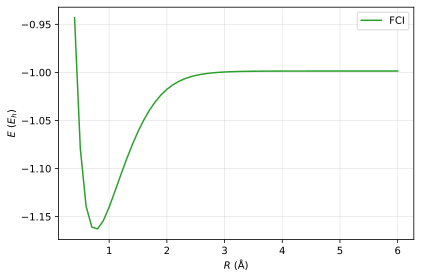

In [3]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))
axes.plot(R, E_FCI, color="tab:green", label="FCI")
axes.set_xlabel(r"$R$ ($\mathrm{\AA}$)"); axes.set_ylabel(r"$E$ ($E_h$)")
axes.legend(); axes.grid(alpha=0.3)
fig.tight_layout(); save_figure(fig, "01_energies"); plt.show()


## 5. Opposite-spin two-body negativity

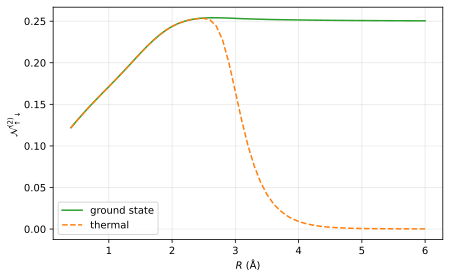

In [4]:
N2 = {state: core.curve(PLOT, state, "n2_ab") for state in ("gs", "thermal")}
fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(R, N2["gs"], color="tab:green", label="ground state")
ax.plot(R, N2["thermal"], color="tab:orange", linestyle="--",
        label=r"thermal")
ax.set_xlabel(r"$R$ ($\mathrm{\AA}$)")
ax.set_ylabel(r"$\mathcal{N}^{(2)}_{\uparrow\downarrow}$")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); save_figure(fig, "02_negativity"); plt.show()

## 6. Mutual informations 

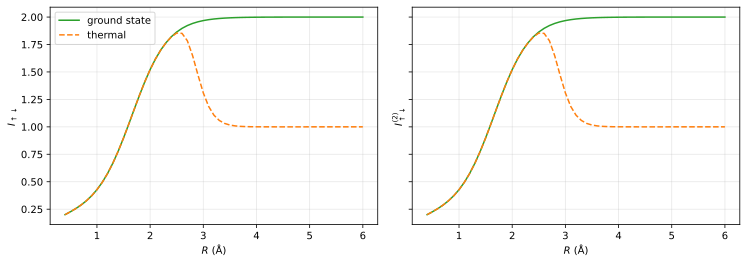

In [5]:
I_GLOBAL = {state: core.curve(PLOT, state, "i_ab") for state in ("gs", "thermal")}
I_TWOBODY = {state: core.curve(PLOT, state, "i2_ab") for state in ("gs", "thermal")}

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8), sharey=True)
for ax, data, label in (
    (axes[0], I_GLOBAL, r"$I_{\uparrow\downarrow}$"),
    (axes[1], I_TWOBODY, r"$I^{(2)}_{\uparrow\downarrow}$"),
):
    ax.plot(R, data["gs"], color="tab:green", label="ground state")
    ax.plot(R, data["thermal"], color="tab:orange", linestyle="--",
            label=r"thermal")
    ax.set_xlabel(r"$R$ ($\mathrm{\AA}$)")
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)
axes[0].legend()
fig.tight_layout(); save_figure(fig, "03_mutual_information"); plt.show()

## 7. Basis-convergence analysis: STO-3G / cc-pVDZ / cc-pVTZ

The same fixed system across three bases. The negativity
peak is related to the basis: absent in STO-3G (monotone approach to $1/4$),
$\approx 0.254$ at $2.7$ Å in cc-pVDZ, growing to $\approx 0.278$ in cc-pVTZ,
while the dissociation asymptotes are basis-stable.

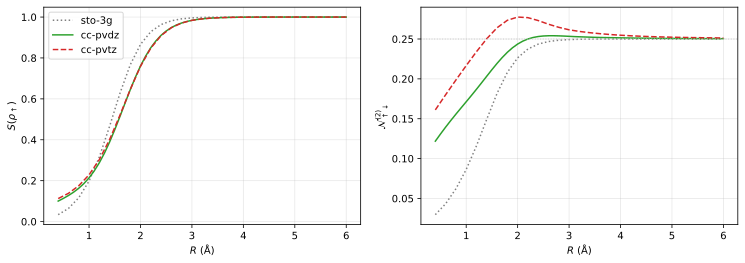

In [6]:
t0 = time.time()
PANEL_GRID = tuple(np.round(np.arange(0.4, 6.0001, 0.2), 10))
PANEL = {basis: [core.lowdin_shull_oracle(r, basis) for r in PANEL_GRID]
         for basis in ("sto-3g", "cc-pvtz")}
STAGE_SECONDS["basis_panel"] = time.time() - t0

CURVES = {
    "sto-3g": (PANEL_GRID, np.array([o["e_ud"] for o in PANEL["sto-3g"]]),
               np.array([o["n_ud"] for o in PANEL["sto-3g"]])),
    "cc-pvdz": (R, core.curve(PLOT, "gs", "e_spin"), core.curve(PLOT, "gs", "n_spin")),
    "cc-pvtz": (PANEL_GRID, np.array([o["e_ud"] for o in PANEL["cc-pvtz"]]),
                np.array([o["n_ud"] for o in PANEL["cc-pvtz"]])),
}
STYLES = {"sto-3g": ("0.5", ":"), "cc-pvdz": ("tab:green", "-"), "cc-pvtz": ("tab:red", "--")}
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for basis, (x, e_ud, n_ud) in CURVES.items():
    color, style = STYLES[basis]
    axes[0].plot(x, e_ud, color=color, linestyle=style, label=basis)
    axes[1].plot(x, n_ud, color=color, linestyle=style, label=basis)
axes[0].set_ylabel(r"$S(\rho_{\uparrow})$")
axes[1].set_ylabel(r"$\mathcal{N}^{(2)}_{\uparrow\downarrow}$")
axes[1].axhline(0.25, color="0.8", linestyle=":", linewidth=1)
for ax in axes:
    ax.set_xlabel(r"$R$ ($\mathrm{\AA}$)"); ax.grid(alpha=0.3)
axes[0].legend()
fig.tight_layout(); save_figure(fig, "04_basis_panel"); plt.show()


## 8. Thermal ensemble

At $\beta = 1000\,E_h^{-1}$, $S(\mathbf{p})$ grows monotonically from $0$ to the two-state dissociation
asymptote of $1$ bit. 

$$
S(\mathbf{p}) = -\sum_n p_n \log_2 p_n,
\qquad
S(\mathbf{q}) = -\sum_n q_n \log_2 q_n,
\qquad
q_n = e^{-\beta (E_n - E_0)},
\quad
p_n = \frac{q_n}{\sum_m q_m}.
$$

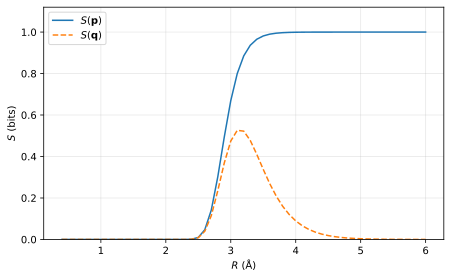

In [7]:
S_P = core.curve(PLOT, "thermal", "s_mixture")

def weight_entropy_bits(q, cutoff=1.0e-300):
    q = np.asarray(q, dtype=float)
    q = q[q > cutoff]
    return float(-(q * np.log2(q)).sum())

S_Q = np.array([
    weight_entropy_bits(np.exp(-BETA * (pt["thermal"]["root_energies"]
                                        - pt["thermal"]["root_energies"].min())))
    for pt in PLOT
])

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(R, S_P, color="tab:blue", label=r"$S(\mathbf{p})$")
ax.plot(R, S_Q, color="tab:orange", linestyle="--", label=r"$S(\mathbf{q})$")
ax.set_ylabel(r"$S$ (bits)")
ax.set_ylim(0.0, 1.12)
ax.set_xlabel(r"$R$ ($\mathrm{\AA}$)")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout(); save_figure(fig, "05_thermal_entropy"); plt.show()

For $(N_\uparrow, N_\downarrow) = (1,1)$ the two-body
$\rho^{(2)}_{\uparrow\downarrow}$ in the ordered product basis is the
complete fixed-sector density matrix, so the thermal
$\rho^{(2)}_{\uparrow\downarrow}(\beta)$, contracted state by state through
the RDM operators, must reproduce the Gibbs state itself: its 100 eigenvalues
equal the Boltzmann weight vector $\{p_n\}$.

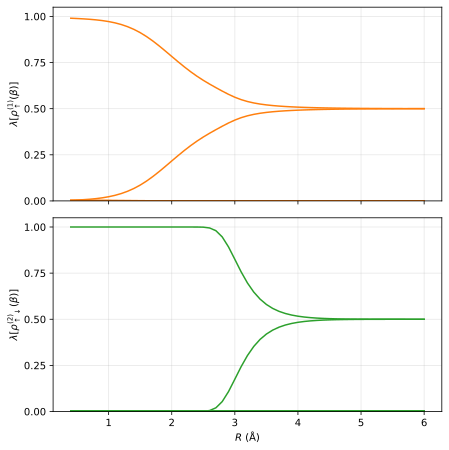

In [8]:
REC0 = PLOT[0]["record"]
BACKEND = core.build_rdm_backend(REC0.norb, *REC0.nelec)
NORB = REC0.norb

RHO1_EIGS = np.empty((len(PLOT), NORB))
GAMMA_EIGS = np.empty((len(PLOT), NORB * NORB))
for k, pt in enumerate(PLOT):
    record = pt["record"]
    weights = np.asarray(pt["thermal"]["weights"])
    states = [BACKEND.adapter.to_mbody(root.ci) for root in record.roots]
    rho1 = BACKEND.plan_1a.contract_mixture(states, weights)
    wedge = BACKEND.plan_2ab.contract_mixture(states, weights)
    product = core.alpha_beta_wedge_to_product(
        wedge, BACKEND.plan_2ab.system_masks, NORB)
    RHO1_EIGS[k] = core.hermitian_spectrum(rho1)[::-1]
    GAMMA_EIGS[k] = core.hermitian_spectrum(product)[::-1]

fig, axes = plt.subplots(2, 1, figsize=(6.4, 6.4), sharex=True)
axes[0].plot(R, RHO1_EIGS, color="tab:orange")
axes[0].set_ylabel(r"$\lambda[\rho^{(1)}_\uparrow(\beta)]$")
axes[1].plot(R, GAMMA_EIGS, color="tab:green")
axes[1].set_ylabel(r"$\lambda[\rho^{(2)}_{\uparrow\downarrow}(\beta)]$")
for ax in axes:
    ax.set_ylim(0.0, 1.05)
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.grid(alpha=0.3)
axes[1].set_xlabel(r"$R$ ($\mathrm{\AA}$)")
fig.tight_layout(); save_figure(fig, "06_thermal_rdm_spectra"); plt.show()
